# Machine Learning XAI Demonstration

``Predicting Agricultural Drought Dynamics in Cavite Using Multi-Year NASA POWER Climatological Data and Random Forest Regression``

by

``Jose Aries E. De Los Santos, M.Sc.``

In [ ]:
# Run this cell first in Google Colab to install XAI packages
%pip install shap

# Import Libraries

In [1]:
import requests
import io
import requests
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

import scipy.stats as stats
# from pygam import LinearGAM, s, f
from PyALE import ale
import shap

# Get Data via API and Extract Features

* ``source 1:`` https://power.larc.nasa.gov/api/temporal/monthly/point
* ``source 2:`` https://power.larc.nasa.gov/api/temporal/monthly/regional



``Input features``:
* T2M_MAX,
* T2M_MIN,
* PRECTOTCORR,
* RH2M,
* ALLSKY_SFC_SW_DWN,
* WS2M
* TS
* EVLAND

``Target``
* GWETROOT

## Point Extraction

In [17]:
url = "https://power.larc.nasa.gov/api/temporal/monthly/point"

#gawa ng dictionary ng municapalities with latitude at longitude
municipalities = [
    {"name": "Bacoor City", "lat": 14.46, "lon": 120.94},
    {"name": "Imus City", "lat": 14.43, "lon": 120.93},
    {"name": "Dasmarinas City", "lat": 14.33, "lon": 120.93},
    {"name": "Tagaytay City", "lat": 14.11, "lon": 120.96},
    {"name": "Naic", "lat": 14.32, "lon": 120.77},
    {"name": "Silang", "lat": 14.23, "lon": 120.97},
    {"name": "Maragondon", "lat": 14.27, "lon": 120.73},
    {"name": "Tanza", "lat": 14.36, "lon": 120.85},
    {"name": "General Trias", "lat": 14.38, "lon": 120.88},
    {"name": "Trece Martires City", "lat": 14.28, "lon": 120.86},
    {"name": "Kawit", "lat": 14.44, "lon": 120.90},
    {"name": "Noveleta", "lat": 14.43, "lon": 120.88},
    {"name": "Cavite City", "lat": 14.48, "lon": 120.90},
    {"name": "Rosario", "lat": 14.41, "lon": 120.85},
    {"name": "Alfonso", "lat": 14.14, "lon": 120.85},
    {"name": "Amadeo", "lat": 14.17, "lon": 120.92},
    {"name": "Indang", "lat": 14.19, "lon": 120.87},
    {"name": "Mendez", "lat": 14.13, "lon": 120.90},
    {"name": "Ternate", "lat": 14.28, "lon": 120.70},
    {"name": "Magallanes", "lat": 14.19, "lon": 120.73},
    {"name": "General Emilio Aguinaldo", "lat": 14.18, "lon": 120.79},
    {"name": "Carmona", "lat": 14.31, "lon": 121.05},
    {"name": "General Mariano Alvarez", "lat": 14.30, "lon": 121.00}
]

all_dfs = []

#Iterate tayo through each municipality
for municipality in municipalities:
    print(f"Fetching data for: {municipality['name']}...")
    
    params = {
        "parameters": "T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN,WS2M,TS,EVLAND,GWETROOT",
        "community": "AG",
        "latitude": municipality["lat"],
        "longitude": municipality["lon"],
        "start": "1990",
        "end": "2025",
        "format": "CSV"
    }
    
    try:
        response = requests.get(url, params=params)
        csv_content = response.text

        header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
        df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)
        
        # --- ATTACH METADATA COLUMNS ---#
        df['Municipality'] =municipality['name']
        df['LAT'] = municipality['lat']
        df['LON'] = municipality['lon']
        
        all_dfs.append(df)
    except Exception as e:
        print(f"Error fetching data for {municipality['name']}: {e}")

#Ipagsama sama ninyo sa iisang DataFrame
master_df = pd.concat(all_dfs, ignore_index=True)

print("\nExtraction complete!")
print("Master Matrix shape:", master_df.shape)

#save ang master dataframe sa isang CSV file
extracted_file = "cavite_weather_master.csv"
master_df.to_csv(extracted_file, index=False)
print(f"Data successfully saved to your local drive as: {extracted_file}")

Fetching data for: Bacoor City...
Fetching data for: Imus City...
Fetching data for: Dasmarinas City...
Fetching data for: Tagaytay City...
Fetching data for: Naic...
Fetching data for: Silang...
Fetching data for: Maragondon...
Fetching data for: Tanza...
Fetching data for: General Trias...
Fetching data for: Trece Martires City...
Fetching data for: Kawit...
Fetching data for: Noveleta...
Fetching data for: Cavite City...
Fetching data for: Rosario...
Fetching data for: Alfonso...
Fetching data for: Amadeo...
Fetching data for: Indang...
Fetching data for: Mendez...
Fetching data for: Ternate...
Fetching data for: Magallanes...
Fetching data for: General Emilio Aguinaldo...
Fetching data for: Carmona...
Fetching data for: General Mariano Alvarez...

Extraction complete!
Master Matrix shape: (7452, 18)
Data successfully saved to your local drive as: cavite_weather_master.csv


# Data Exploration and Cleaning

## Read the downloaded csv file via pandas

In [2]:
df = pd.read_csv("cavite_weather_master.csv")

## Summary Statistics

In [3]:
print(f"{df.describe()}")

              YEAR          JAN          FEB          MAR          APR  \
count  7452.000000  7452.000000  7452.000000  7452.000000  7452.000000   
mean   2007.500000    20.585828    20.667438    20.862921    21.156461   
std      10.388992    24.157812    23.362642    22.586361    21.937177   
min    1990.000000     0.130000     0.040000     0.100000     0.090000   
25%    1998.750000     2.710000     1.980000     1.640000     1.400000   
50%    2007.500000    16.610000    18.920000    21.360000    23.060000   
75%    2016.250000    26.860000    27.760000    29.610000    31.800000   
max    2025.000000    91.480000    89.630000    89.240000    87.070000   

               MAY          JUN          JUL          AUG          SEP  \
count  7452.000000  7452.000000  7452.000000  7452.000000  7452.000000   
mean     22.003904    22.725643    22.974975    23.033371    22.830103   
std      22.705074    23.862301    24.545858    24.844613    24.873567   
min       0.440000     0.520000     0

## Data Reshape

In [4]:
#Reshape monthly columns (JAN-DEC) into a single MONTH column
month_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
id_cols = [col for col in df.columns if col not in month_cols and col != 'ANN']

df_long = df.melt(id_vars=id_cols, value_vars=month_cols, var_name='MONTH_NAME', value_name='VALUE')

#Convert Month names to numbers (1 to 12)
month_map = {'JAN':1, 'FEB':2, 'MAR':3, 'APR':4, 'MAY':5, 'JUN':6,
             'JUL':7, 'AUG':8, 'SEP':9, 'OCT':10, 'NOV':11, 'DEC':12}
df_long['MONTH'] = df_long['MONTH_NAME'].map(month_map)

#Pivot weather parameters into individual feature columns
if 'PARAMETER' in df_long.columns:
    index_cols = [col for col in df_long.columns if col not in ['PARAMETER', 'VALUE', 'MONTH_NAME']]
    df = df_long.pivot(index=index_cols, columns='PARAMETER', values='VALUE').reset_index()

#Ensure LAT and LON exist so the duplicate check doesn't throw an error
if 'LAT' not in df.columns:
    df['LAT'] = params['latitude']
if 'LON' not in df.columns:
    df['LON'] = params['longitude']

print("Data successfully reshaped!")
print(df.head())
new_file = "cavite_weather_master_reshaped.csv"
df.to_csv(new_file, index=False)

Data successfully reshaped!
PARAMETER  YEAR Municipality    LAT     LON  MONTH  ALLSKY_SFC_SW_DWN  EVLAND  \
0          1990      Alfonso  14.14  120.85      1              18.17    1.96   
1          1990      Alfonso  14.14  120.85      2              21.72    0.64   
2          1990      Alfonso  14.14  120.85      3              22.51    0.72   
3          1990      Alfonso  14.14  120.85      4              24.96    0.17   
4          1990      Alfonso  14.14  120.85      5              21.21    2.09   

PARAMETER  GWETROOT  PRECTOTCORR   RH2M  T2M_MAX  T2M_MIN     TS  WS2M  
0              0.50         0.67  78.89    30.46    21.78  26.27  4.23  
1              0.46         0.11  74.10    32.15    22.60  27.01  4.22  
2              0.45         0.57  69.46    33.94    22.87  27.89  3.57  
3              0.44         0.09  67.50    34.56    24.77  29.92  3.17  
4              0.50         6.31  74.77    35.56    26.07  29.67  2.81  


## Check duplicates and remove them if necessary

In [5]:
# df.columns
num_of_dups = df.duplicated(subset=['LAT', 'LON', 'YEAR', 'MONTH']).sum()
if num_of_dups > 0:
    print(f"Warning: There are {num_of_dups} duplicate rows based on LAT, LON, YEAR, and MONTH.")
    df = df.drop_duplicates(subset=['LAT', 'LON', 'YEAR', 'MONTH'])
else:
    print("No duplicate rows found based on LAT, LON, YEAR, and MONTH.")

No duplicate rows found based on LAT, LON, YEAR, and MONTH.


## Check for Missing or NaN values then drop them

In [6]:
print(f"Missing Values:\n\n{df.isna().sum()}")
missing_values = df.isna().sum()
if missing_values.any():
    print("Warning: There are missing values in the dataset. Consider handling them before modeling.")
    df = df.dropna()
    print(f"Missing values after cleaning:\n{df.isna().sum()}")
    print(f"new shape after dropping missing values: {df.shape}")
else:
    print("No missing values found in the dataset.")

Missing Values:

PARAMETER
YEAR                 0
Municipality         0
LAT                  0
LON                  0
MONTH                0
ALLSKY_SFC_SW_DWN    0
EVLAND               0
GWETROOT             0
PRECTOTCORR          0
RH2M                 0
T2M_MAX              0
T2M_MIN              0
TS                   0
WS2M                 0
dtype: int64
No missing values found in the dataset.


## Check for Negative Values

In [7]:
# Negative values in target variable (GWETROOT) should be between 0 and 1
invalid_gwet = df[(df['GWETROOT'] < 0) | (df['GWETROOT'] > 1)]
print(f"Invalid target values: {len(invalid_gwet)}")

#Physical non-negative variables
non_negative_cols = ['PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'RH2M']
for col in non_negative_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        print(f"Negative values in {col}: {neg_count}")

Invalid target values: 0
Negative values in PRECTOTCORR: 0
Negative values in ALLSKY_SFC_SW_DWN: 0
Negative values in WS2M: 0
Negative values in RH2M: 0


## Ensure Correct Numeric Data Types (dtypes)

* scikit-learn models require all input columns to be numerical (``float64`` or ``int64``). If MONTH or any weather column is currently stored as a string (object), the model fitting step will throw a ``TypeError``.

In [8]:
# Verify column data types
print(df.dtypes)

PARAMETER
YEAR                   int64
Municipality             str
LAT                  float64
LON                  float64
MONTH                  int64
ALLSKY_SFC_SW_DWN    float64
EVLAND               float64
GWETROOT             float64
PRECTOTCORR          float64
RH2M                 float64
T2M_MAX              float64
T2M_MIN              float64
TS                   float64
WS2M                 float64
dtype: object


# Data Preprocessing

## Extract Feature Matrix and Target Variable

In [9]:
X = df[["MONTH", "T2M_MAX", "T2M_MIN", "PRECTOTCORR",
        "RH2M", "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND"]]
y = df["GWETROOT"]

print(f"Feature matrix shape X: {X.shape}")
print(f"Target array shape y: {y.shape}")

Feature matrix shape X: (9936, 9)
Target array shape y: (9936,)


## Split the Data for Training and Testing

In [10]:
### 80% yung nasa training data and 20% yung nasa testing data/unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest Regressor Model
* Just use the built-in from Scikit-Learn

## Hyperparameter tuning


* To optimize the Random Forest Regressor, we defined a parameter space controlling the forest's size and the complexity of individual trees. Instead of exhaustively testing every possible combination, we utilized a Randomized Search to sample diverse configurations efficiently. Each candidate model was evaluated using cross-validation to ensure it generalizes well to unseen data, with the ultimate goal of selecting the parameter set that achieved the lowest Mean Squared Error (MSE)

In [11]:
## Define the grid of parameters 
param_distributions = {
    'n_estimators': [100, 150, 200, 250, 300, 350, 400, 450, 500],
    'max_depth': [None, 10, 15, 20, 25, 30, 35, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

## initialize the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

## Set up the random search (e.g., test 20 random combinations with 3-fold cross-validation)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_distributions, 
    n_iter=20,          
    cv=5,               
    verbose=2,          
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error' # Optimize for lowest MSE
)
rf_random.fit(X_train, y_train)
print(rf_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 350, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 35}


## Fitting the model

In [13]:
## Initialize the model with the best parameters found by RandomizedSearchCV
rf_model = RandomForestRegressor(**rf_random.best_params_, random_state=42, n_jobs=-1)
## Train model
rf_model.fit(X_train, y_train)
## Predict
y_pred = rf_model.predict(X_test)

## Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"R^{2} Score: {r2:.7f}")
print(f"MSE:      {mse:.7f}")
print(f"RMSE:     {rmse:.7f}")
print(f"MAE:      {mae:.7f}")

--- MODEL PERFORMANCE EVALUATION ---
R^2 Score: 0.9986347
MSE:      0.0000364
RMSE:     0.0060294
MAE:      0.0023985


## Visualize Sample Tree

In [37]:
from sklearn.tree import plot_tree
single_tree = rf_model.estimators_[100]


fig, ax = plt.subplots(figsize=(20, 10), dpi=600)

plot_tree(
    single_tree, 
    feature_names=X_train.columns,  
    filled=True, 
    rounded=True, 
    max_depth=3,
    fontsize=12,          
    precision=2,         
    proportion=True,      
    ax=ax
    )            

plt.title("Sample Decision Pathway for Drought Risk", fontsize=18, fontweight='bold', pad=10)
plt.tight_layout()        # Ensures the edges of the plot don't get cut off when saving
plt.show()

# XAI

## SHAP

In [15]:
#SHAP EXPLAINER & EXPLANATION OBJECT

### --> Take a random sample from the test set
sample = X_test.sample(n=600, random_state=145)

explainer = shap.TreeExplainer(rf_model)
shap_values_array = explainer.shap_values(sample)
explanation = explainer(sample)

### SHAP BEESWARM SUMMARY PLOT (Global Interpretability)


``How to interpret a beeswarm plot``

A SHAP beeswarm plot combines global feature importance with local impact distributions, displaying how feature values across every sample in your dataset drive predictions higher or lower.

Key Visual Components

* **Y-axis (Feature Ranking):** Features are ordered from top to bottom by overall impact (mean absolute SHAP value). The top features are the most important globally.
* **X-axis (SHAP Value):** Indicates the direction and magnitude of impact on the model prediction for a single instance:
  * **Right side ($> 0$):** Pushes the prediction higher.
  * **Left side ($< 0$):** Pushes the prediction lower.
* **Dot Color (Feature Value):** Indicates the actual value of the feature for that observation:
  * **Red / Warm colors:** High feature values relative to the dataset.
  * **Blue / Cool colors:** Low feature values relative to the dataset.
* **Dot Density (Vertical Spread):** The thickness of the band at any given $X$-position indicates how many instances in your dataset share that exact SHAP value.

---

``How to Read a Feature Row``

To interpret any single feature, trace the color distribution along the horizontal axis:

``1. Positive Relationship (Red on Right, Blue on Left)``
* High feature values (red) result in positive SHAP values, driving predictions up.
* Low values (blue) drive predictions down.

``2. Inverse Relationship (Blue on Right, Red on Left)``
* Low feature values (blue) drive predictions up.
* High values (red) push predictions down.

``3. Asymmetric or Tail Effects``
* If dots cluster near $0$ for most samples but stretch far to the right or left for a few, the feature acts as a strong trigger for a small subset of data rather than having a steady uniform effect.

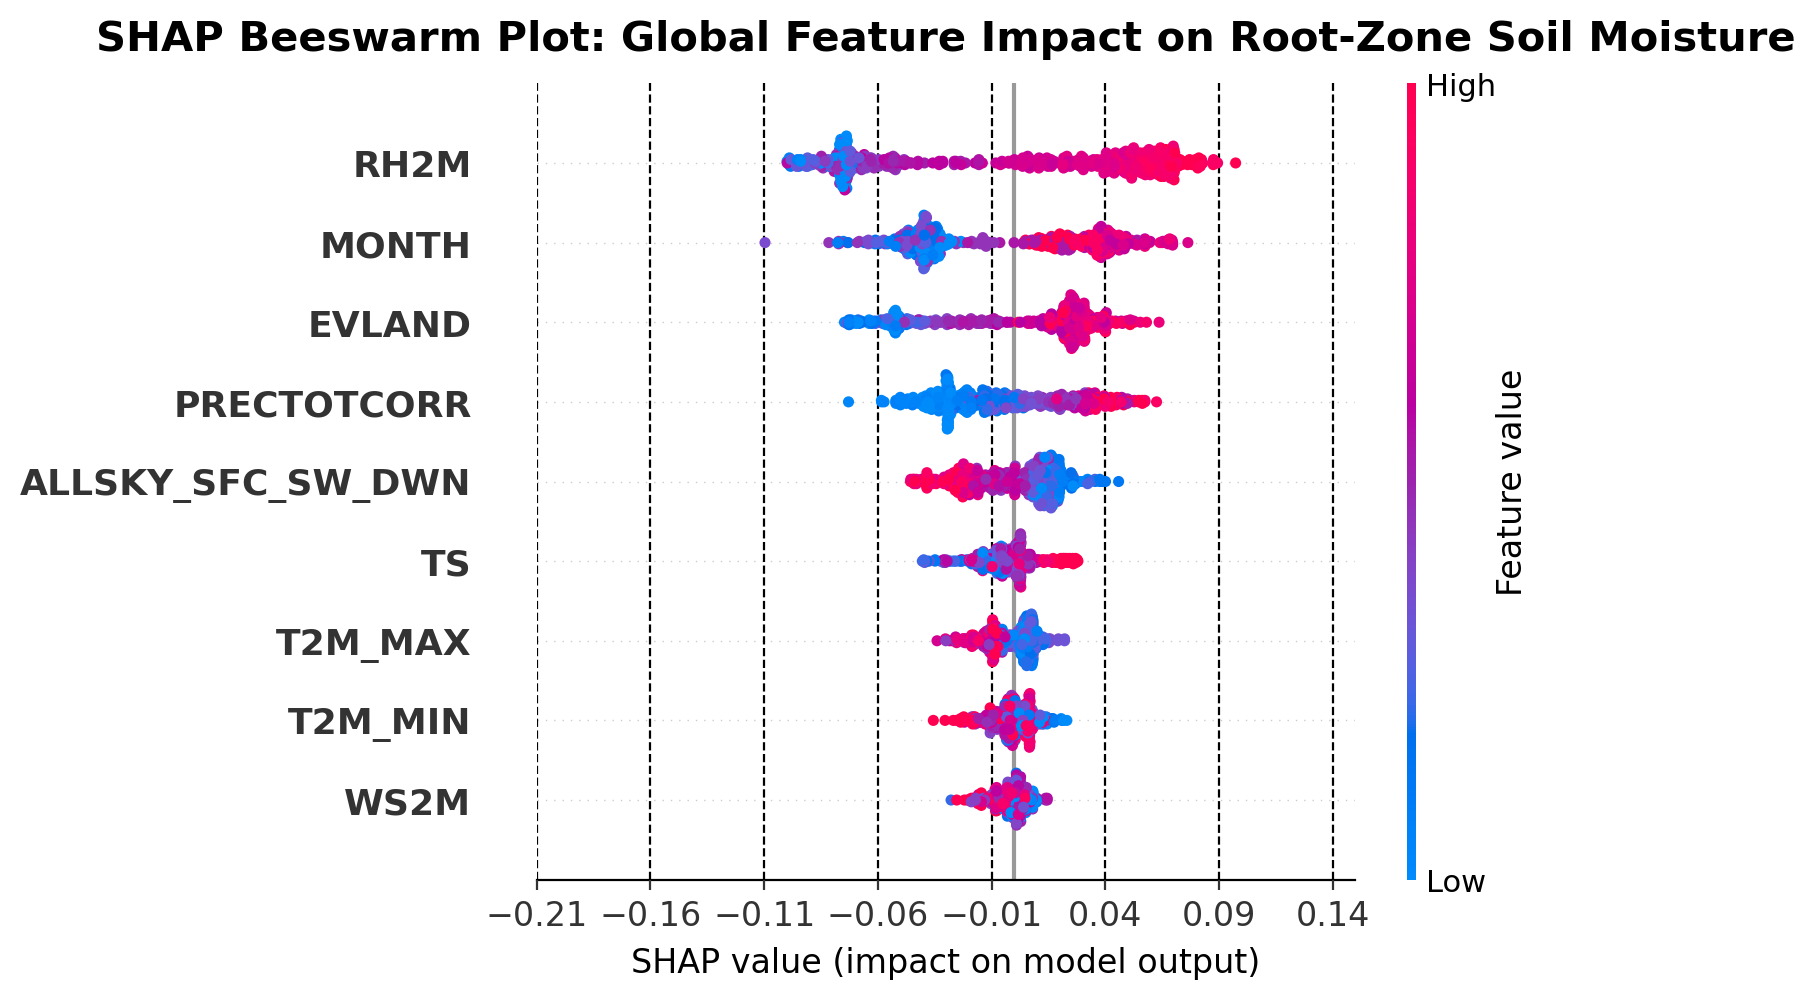

In [16]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
#Draw SHAP beeswarm plot
shap.plots.beeswarm(explanation, max_display=10, show=False)
x_min, x_max = -0.21, 0.15
plt.xlim(x_min, x_max)
plt.xticks(np.arange(x_min, x_max + 0.001, 0.05), fontsize=12)
plt.yticks(fontsize=13, fontweight='bold')
ax.set_axisbelow(False)
plt.grid(True, axis='x', linestyle='--', alpha=1.0, color='#000000')
plt.title(
    "SHAP Beeswarm Plot: Global Feature Impact on Root-Zone Soil Moisture",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
plt.xlabel("SHAP value (impact on model output)", fontsize=12, labelpad=5)
plt.tight_layout()
# plt.savefig("shap_beeswarm_plot.png", dpi=300, bbox_inches='tight')
plt.show()

#### <h2>Interpreting SHAP Beeswarm Plots: Root-Zone Soil Moisture Model</h2>

<h2>Overview of Model Predictions</h2>
In this Random Forest Regressor model predicting **Root-Zone Soil Wetness (`GWETROOT`)**, global feature importance is heavily dominated by atmospheric moisture indicators (`RH2M`) and land surface water fluxes (`EVLAND`), followed by direct mass input (`PRECTOTCORR`).

---
The beeswarm plot establishes the hierarchy of climatological drivers affecting Cavite’s root-zone soil moisture. Relative Humidity (RH2M) emerged as the most dominant predictive feature, exhibiting a strong positive correlation where highly humid conditions prevented soil drying. The model also successfully captured seasonal temporality, ranking MONTH as the second highest driver, reflecting the province's distinct wet and dry monsoon cycles. Furthermore, the model demonstrated physical validity regarding solar radiation (ALLSKY_SFC_SW_DWN); the feature attribution reveals an inverse relationship where high surface radiation (red points) strictly exerts a negative SHAP impact, actively driving drought conditions through enhanced surface evaporation. Notably, atmospheric temperatures (TS, T2M_MAX) ranked lower in global importance compared to direct moisture variables like precipitation (PRECTOTCORR) and humidity.

Rainfall tells the model if it rained today, but the MONTH variable gives the model the seasonal context. A single heavy rainstorm in April (Dry Season) will evaporate very quickly because the ground is baked dry. But that exact same rainstorm in September (Wet Season) will soak into the roots because the soil is already continuously saturated. The model ranked MONTH as the #2 driver because soil moisture relies heavily on long-term seasonal baselines, not just daily weather.

* Low Values (1, 2, 3, 4, 5): These are January through May. Because these numbers are low, SHAP colors them Blue. As you can see on the plot, these blue dots stretch to the left (negative impact on soil moisture).

* High Values (8, 9, 10, 11, 12): These are August through December. Because these numbers are high, SHAP colors them Red/Pink. These dots sit firmly on the right side (positive impact on soil moisture).

* Middle Values (6, 7): These are June and July (the transition months). SHAP colors these Purple, and you can see them floating near the middle of the zero-line!

### SHAP Waterfall Plot

---
A SHAP waterfall plot explains a **single local prediction** by breaking down how each feature's contribution moves the model output from the baseline value to the final prediction.

---

``Key Visual Components``

* **Baseline Value $E[f(X)]$ (Bottom of Plot):** The expected (average) output value of the model across the entire dataset. This serves as the starting anchor. (e.g. $E[f(X)] = 0.845$: This is the **baseline**. If the model had to guess the root-zone soil moisture without knowing any of the specific weather conditions for this sample, it would guess $0.845$. This is the average prediction across the ``training dataset``.)
* **Final Prediction $f(x)$ (Top of Plot):** The model's actual predicted output for this specific individual instance.
* **Horizontal Bars & Direction:**
  * **Red / Pink Bars (Positive Impact):** Point right and increase the prediction relative to the baseline ($+\phi_i$).
  * **Blue Bars (Negative Impact):** Point left and decrease the prediction relative to the baseline ($-\phi_i$).
* **Bar Length:** Represents the magnitude of the feature's influence on this specific prediction. Longer bars indicate stronger effects.
* **Feature Names & Values (Y-axis):** Listed on the left alongside their actual raw numerical values for this sample.
* **SHAP Values ($\phi_i$):** Numbers displayed inside or directly next to the arrows showing the exact numerical shift added or subtracted by each feature.

---

``Step-by-Step Interpretation Guide``

`1.` **Locate the Baseline ($E[f(X)]$):** Start at the bottom axis value. This is what the model would predict on average without knowing specific feature values for this instance.

`2.` **Trace the Cumulative Shifts (Bottom to Top):** Move upward row by row. Each row shows how much a feature pushes the prediction higher (red) or lower (blue) from the running total.

`3.` **Identify the Dominant Drivers:** Features near the top of the waterfall generally have the largest contribution to pushing the prediction away from the mean.

`4.` **Verify the Additive Sum:** The sum of all individual SHAP values added to the baseline equals the final output:

$$f(x) = E[f(X)] + \sum_{i=1}^{M} \phi_i$$

---

In [24]:
explanation[200]

.values =
array([-0.0345537 , -0.00624047,  0.00391528, -0.02106266, -0.06815152,
       -0.02215924, -0.00014865,  0.00090964, -0.02131836])

.base_values =
0.7985239629017182

.data =
array([ 3.  , 32.99, 22.4 ,  1.23, 72.28, 22.62,  3.85, 29.25,  2.51])

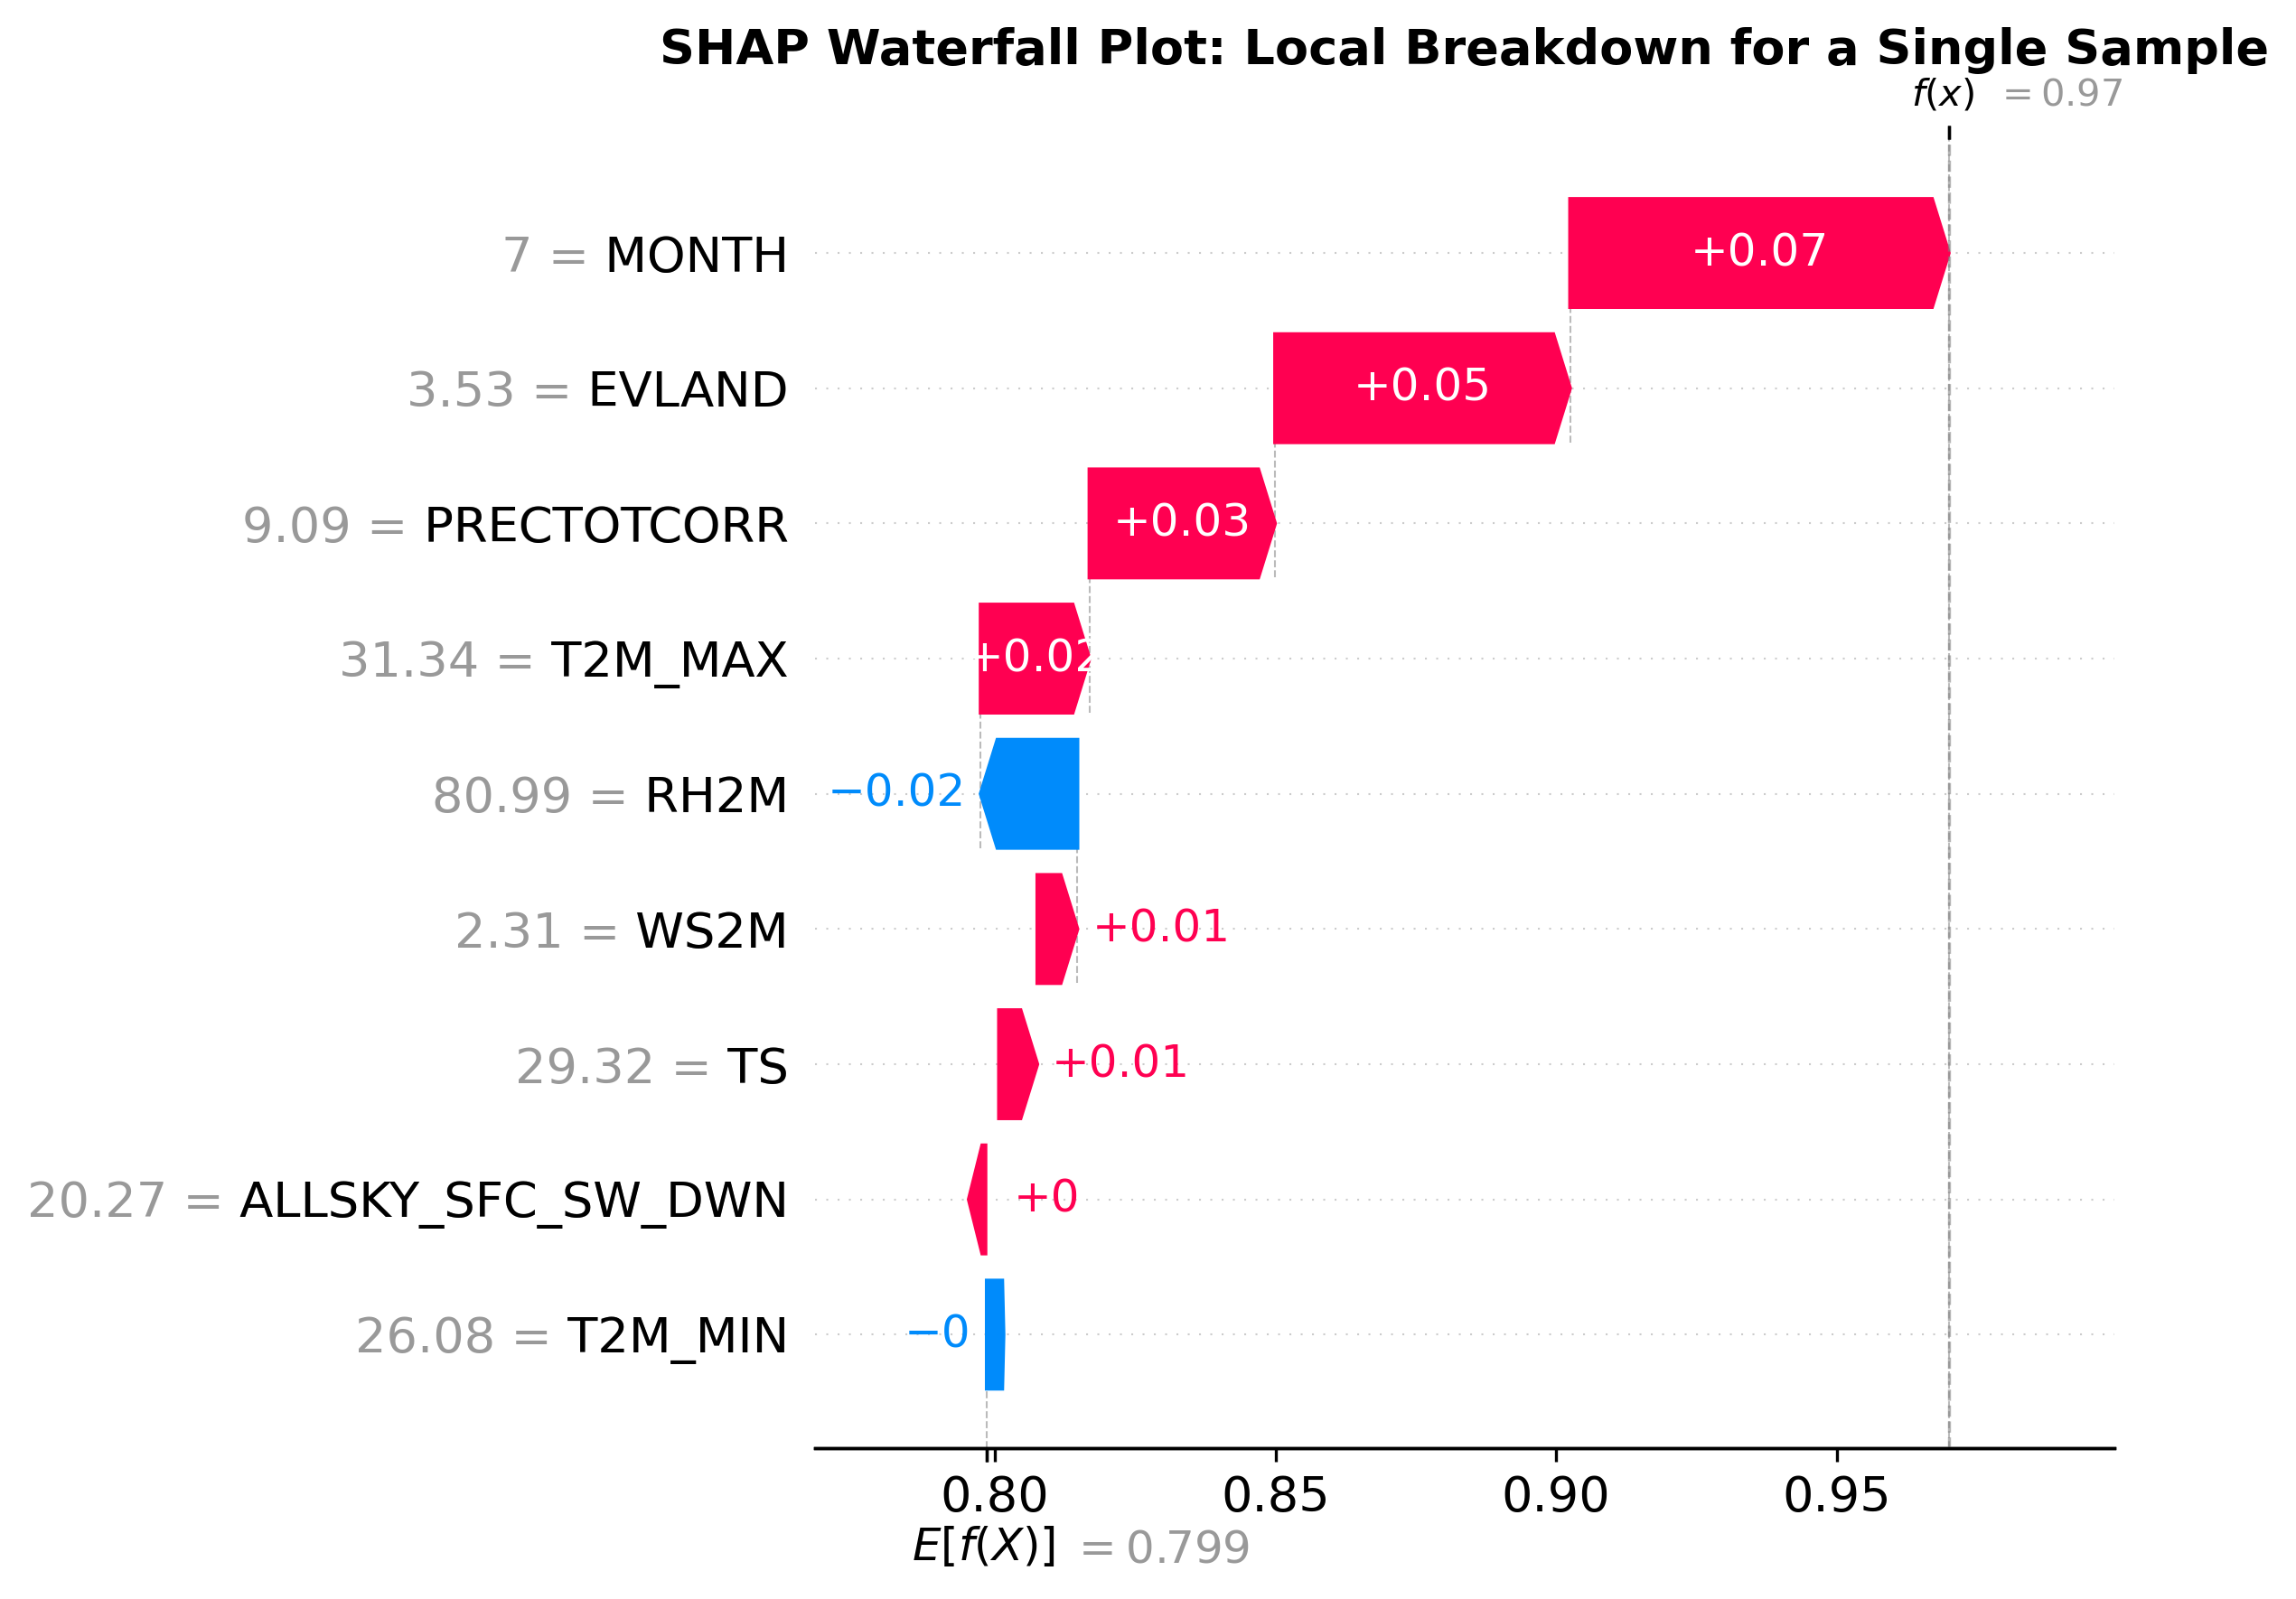

In [26]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

shap.plots.waterfall(explanation[300], show=False)

plt.gca().set_axisbelow(True)
plt.grid(True, axis="x", linestyle="--", alpha=0.35, color="gray")

plt.title(
    "SHAP Waterfall Plot: Local Breakdown for a Single Sample",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### SHAP Waterfall Plot: Single Sample (Local) Explanation

> **CRITICAL NOTE:** Unlike global plots (like the Beeswarm or Heatmap) that show overall trends across the entire dataset, the Waterfall Plot is strictly a **local explanation**. It explains the model's exact decision-making process for **one single row of data** (e.g., one specific day or location). It shows how the specific feature values of this one sample pushed the prediction away from the global average.

---

``Visual Breakdown for this Specific Instance``

**The Starting Point (Baseline: $E[f(X)] = 0.799$)**
* This is the foundation of the plot. If the model had to guess the root-zone soil moisture without knowing *any* of the specific weather conditions for this single sample, it would guess $0.799$. This represents the average prediction across the entire training dataset.

``The Additions (Red Bars = Making Soil Wetter)``
The model then looks at this month's specific weather and starts adding points to the baseline:
* MONTH = 7 (July): Because July is the start of the wet season (Habagat), the model immediately adds $+0.07$ to the soil moisture prediction. This was the single biggest factor for this month.
* EVLAND = 3.53: High evaporation (meaning surface water is actively evaporating because it rained) adds another $+0.05$.
* PRECTOTCORR = 9.09: The physical rainfall itself adds $+0.03$.

``The Subtractions (Blue Bars = Making Soil Drier)``
* RH2M = 80.99: The relative humidity was around 81%. The air wasn't fully saturated, it acted as a slight drying force, subtracting $-0.02$ from the total. 

``The Final Prediction``
Observe that $f(x) = 0.97$. The model took the baseline ($0.799$), added the red bars, subtracted the blue bar, and arrived at a final predicted soil moisture of $0.97$.Agricultural Meaning: At 0.97, the root-zone is 97% saturated. This is a flooded or completely waterlogged month. Drought risk is zero.

### SHAP Heatmap



The SHAP heatmap visualizes the entire dataset's explanations at once, organizing samples to reveal macro-level patterns in how features drive the model's predictions.

``Key Visual Components``

* **X-axis (Instances):** Each vertical column represents a single sample from your dataset. SHAP automatically orders these instances by their final predicted value, from lowest on the left to highest on the right.
* **Top Line Graph ($f(x)$):** This black line shows the model's final prediction for each instance. It slopes upward from left to right because the underlying instances are sorted by this exact output.
* **Y-axis (Features):** Features are ranked top-to-bottom by their overall global importance. The solid black bars on the far right show the mean absolute SHAP value for each feature (essentially a built-in summary bar plot).
* **Color Scale:**
  * **Red (Positive):** The feature *increased* the model's prediction for that specific instance.
  * **Blue (Negative):** The feature *decreased* the model's prediction for that specific instance.
  * **White (Neutral):** The feature had zero or near-zero impact on the prediction.

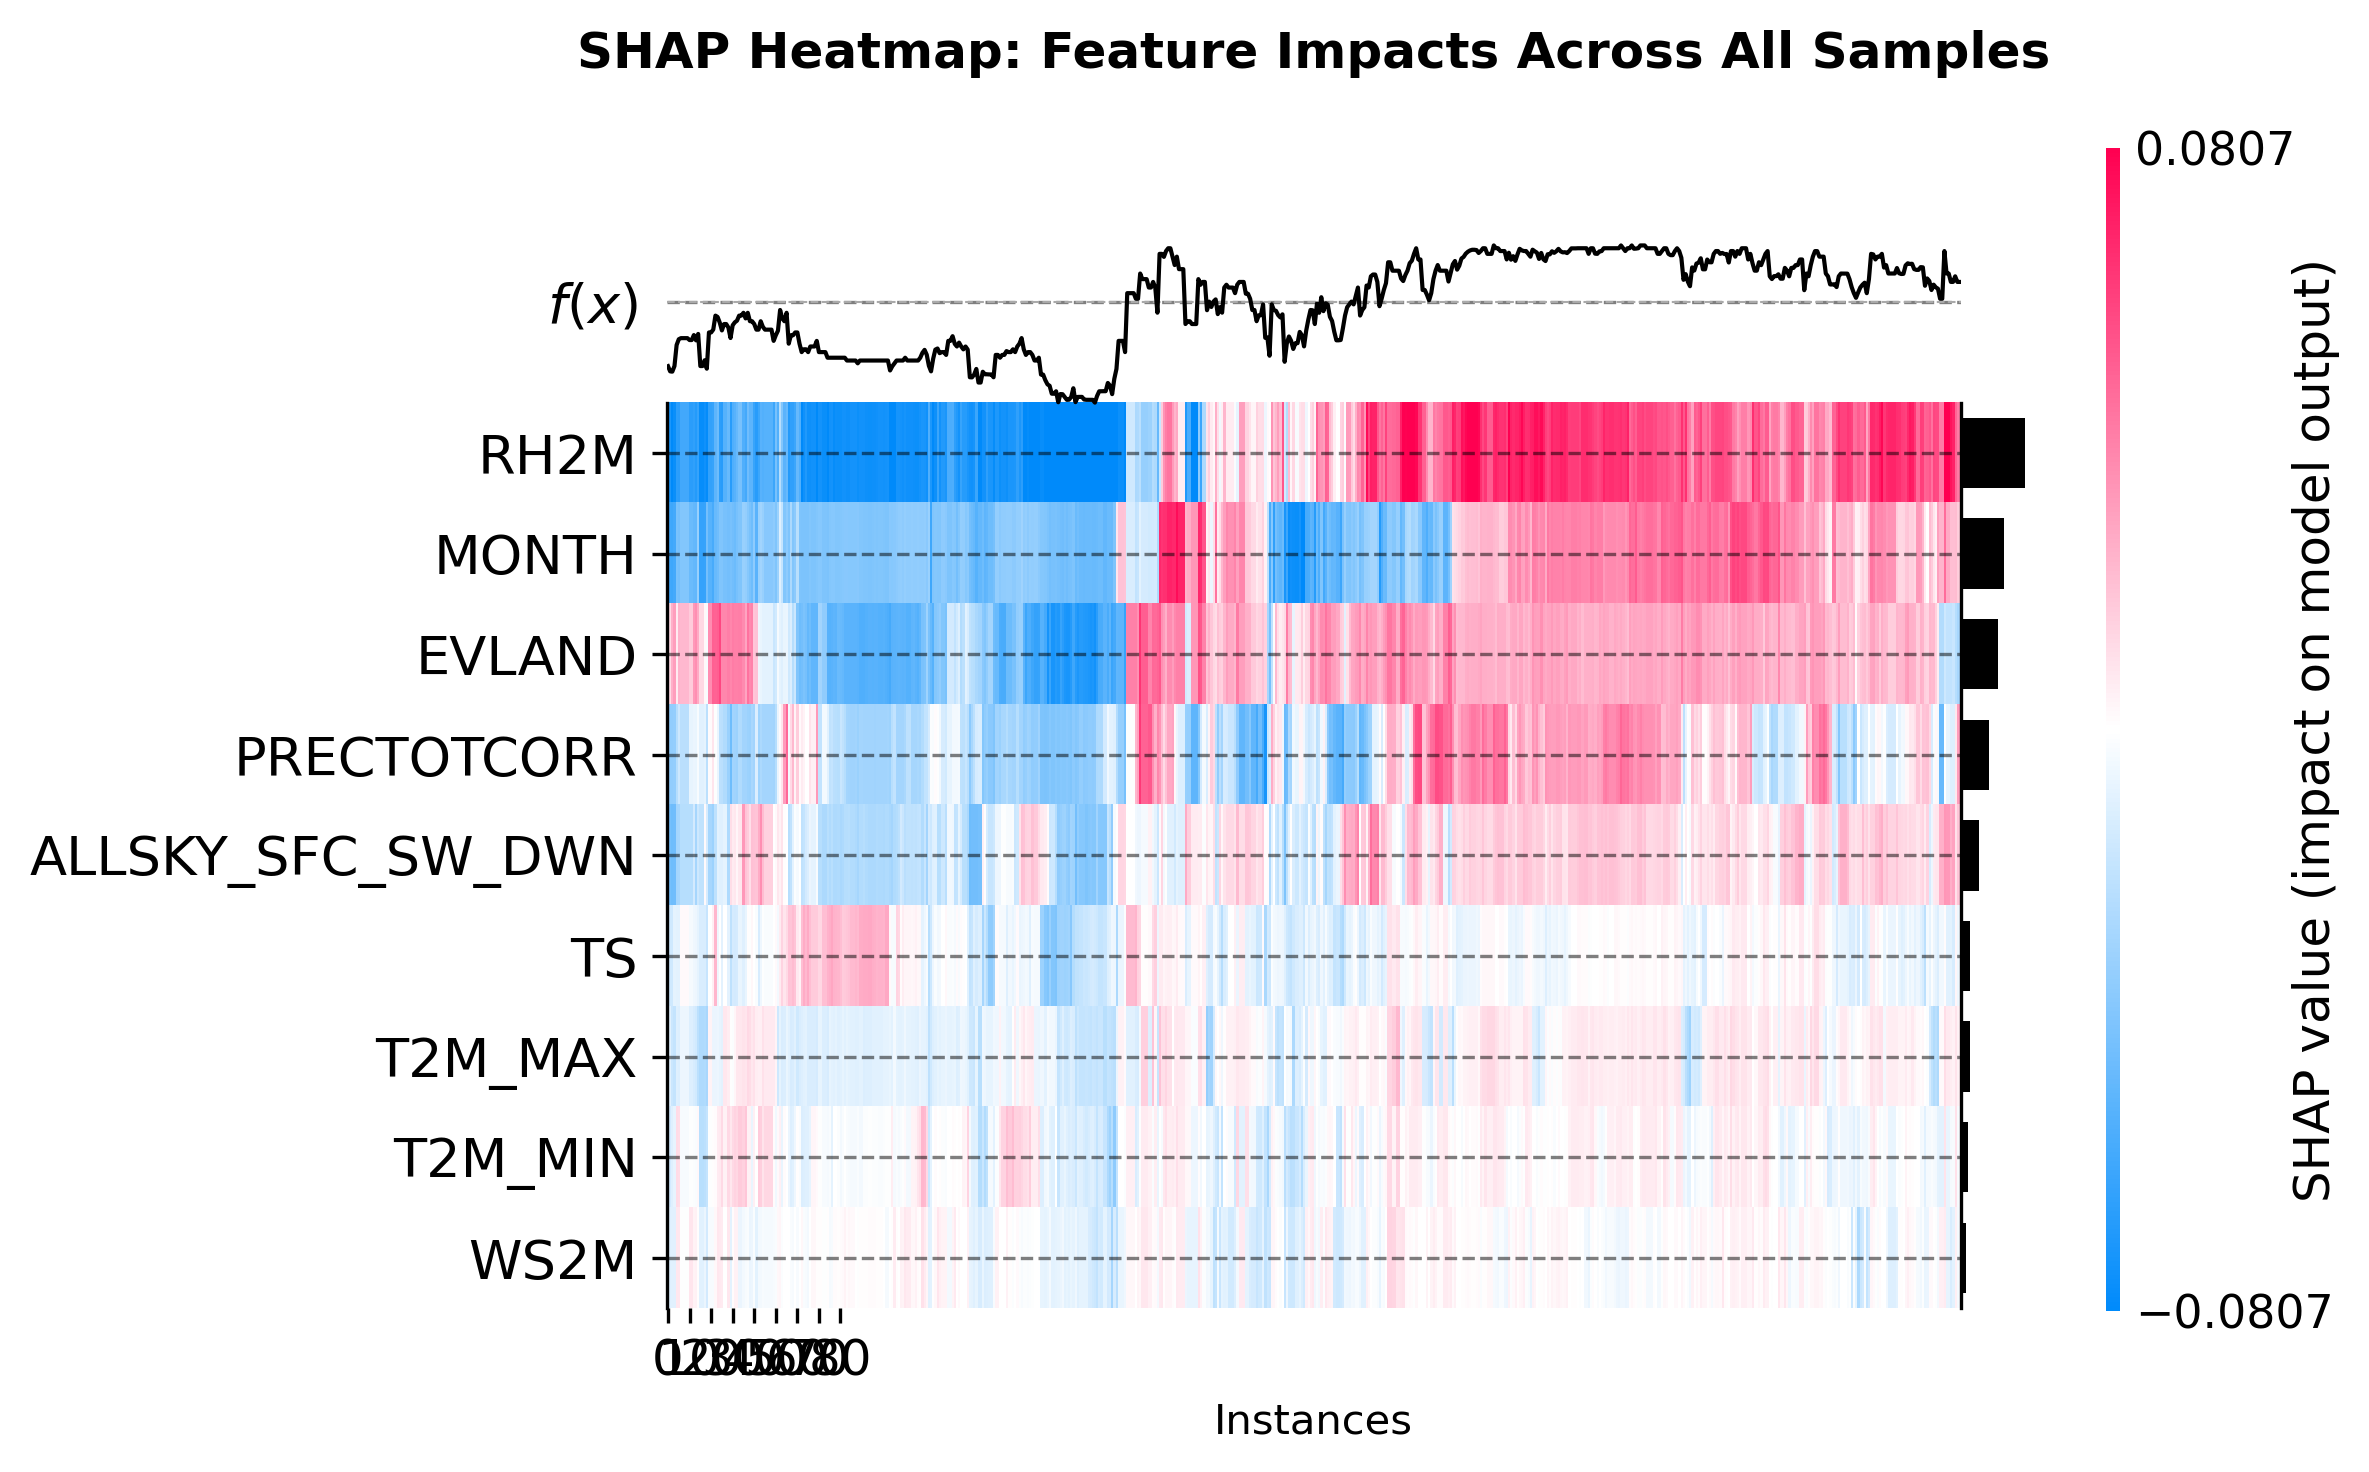

In [18]:
plt.figure(figsize=(12, 6), dpi=300)

# Plot heatmap for the whole dataset (or a subset like explanation[:1000])
# shap.plots.heatmap(explanation, show=False)
shap.plots.heatmap(explanation[:1000], show=False)  # Optional: Limit to first 1000 samples for clarity
plt.gca().set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.5, color='#000000')
plt.xticks(np.arange(0, 90, 10), fontsize=12)
plt.title("SHAP Heatmap: Feature Impacts Across All Samples", pad=20, fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretation:

To evaluate macro-level prediction patterns, a SHAP heatmap is generated to cluster instances with similar feature impacts. The $f(x)$ line at the upper margin tracks the model's final soil moisture prediction. The heatmap reveals two distinct climatological regimes. On the left, a severe drought cluster (low $f(x)$) is dominantly driven by negative SHAP values from Relative Humidity (RH2M), indicated by the dense blue region. Conversely, the saturated cluster on the right (high $f(x)$) is characterized by a unified block of positive SHAP impacts from RH2M and temporal seasonality (MONTH). This clustering confirms that extreme soil moisture states in Cavite are not driven by isolated anomalies, but by synchronized shifts in humidity and seasonal timing

### SHAP Dependence Plots

``How to Read a SHAP Dependence Plot``

A SHAP dependence plot is the best way to see exactly how a single feature affects your model's predictions across your entire dataset. It acts like a traditional scatter plot, but with the added superpower of revealing hidden **interactions** between variables.

Here is a clear, step-by-step breakdown of how to interpret it:

``1. The X-Axis (Feature Value)``
* This is the actual, real-world numerical value of the feature you are analyzing (e.g., your Relative Humidity percentage).
* You read it from left to right, going from the lowest recorded values in your dataset to the highest.

``2. The Y-Axis (SHAP Value / Model Impact)``
* This represents how much that specific feature value **changed the model's prediction** away from the baseline average.
* **Above the 0.0 line (Positive):** This specific value pushed the model's prediction *higher*.
* **Below the 0.0 line (Negative):** This specific value dragged the model's prediction *lower*.
* **Exactly on the 0.0 line:** This specific value had absolutely zero impact on the model's output.

``3. The Shape (The Main Trend)``
* Look at the overall shape of the dot cluster to understand the core rule the model learned.
* **Linear:** A straight diagonal line means the feature scales evenly (e.g., more rain always equals more soil moisture).
* **Non-linear / Tipping Points:** A flat line that suddenly spikes or drops indicates a threshold. For example, if the dots suddenly shoot upward after 84% humidity, the model learned that humidity only matters after it crosses that specific saturation point.

``4. The Color Scale (Feature Interactions)``
* SHAP automatically colors the dots using a **second feature** to show how two variables work together.
* Look at the vertical spread of the dots at any single point on the X-axis. If dots at the exact same humidity level are scattered vertically, it is because of that second color-coded feature!
* **How to decode it:** If the dots sitting higher up on the Y-axis are pink/red (high evaporation) and the dots sitting lower down are blue (low evaporation), it tells you exactly how evaporation combined with humidity to change the model's prediction for those specific samples.

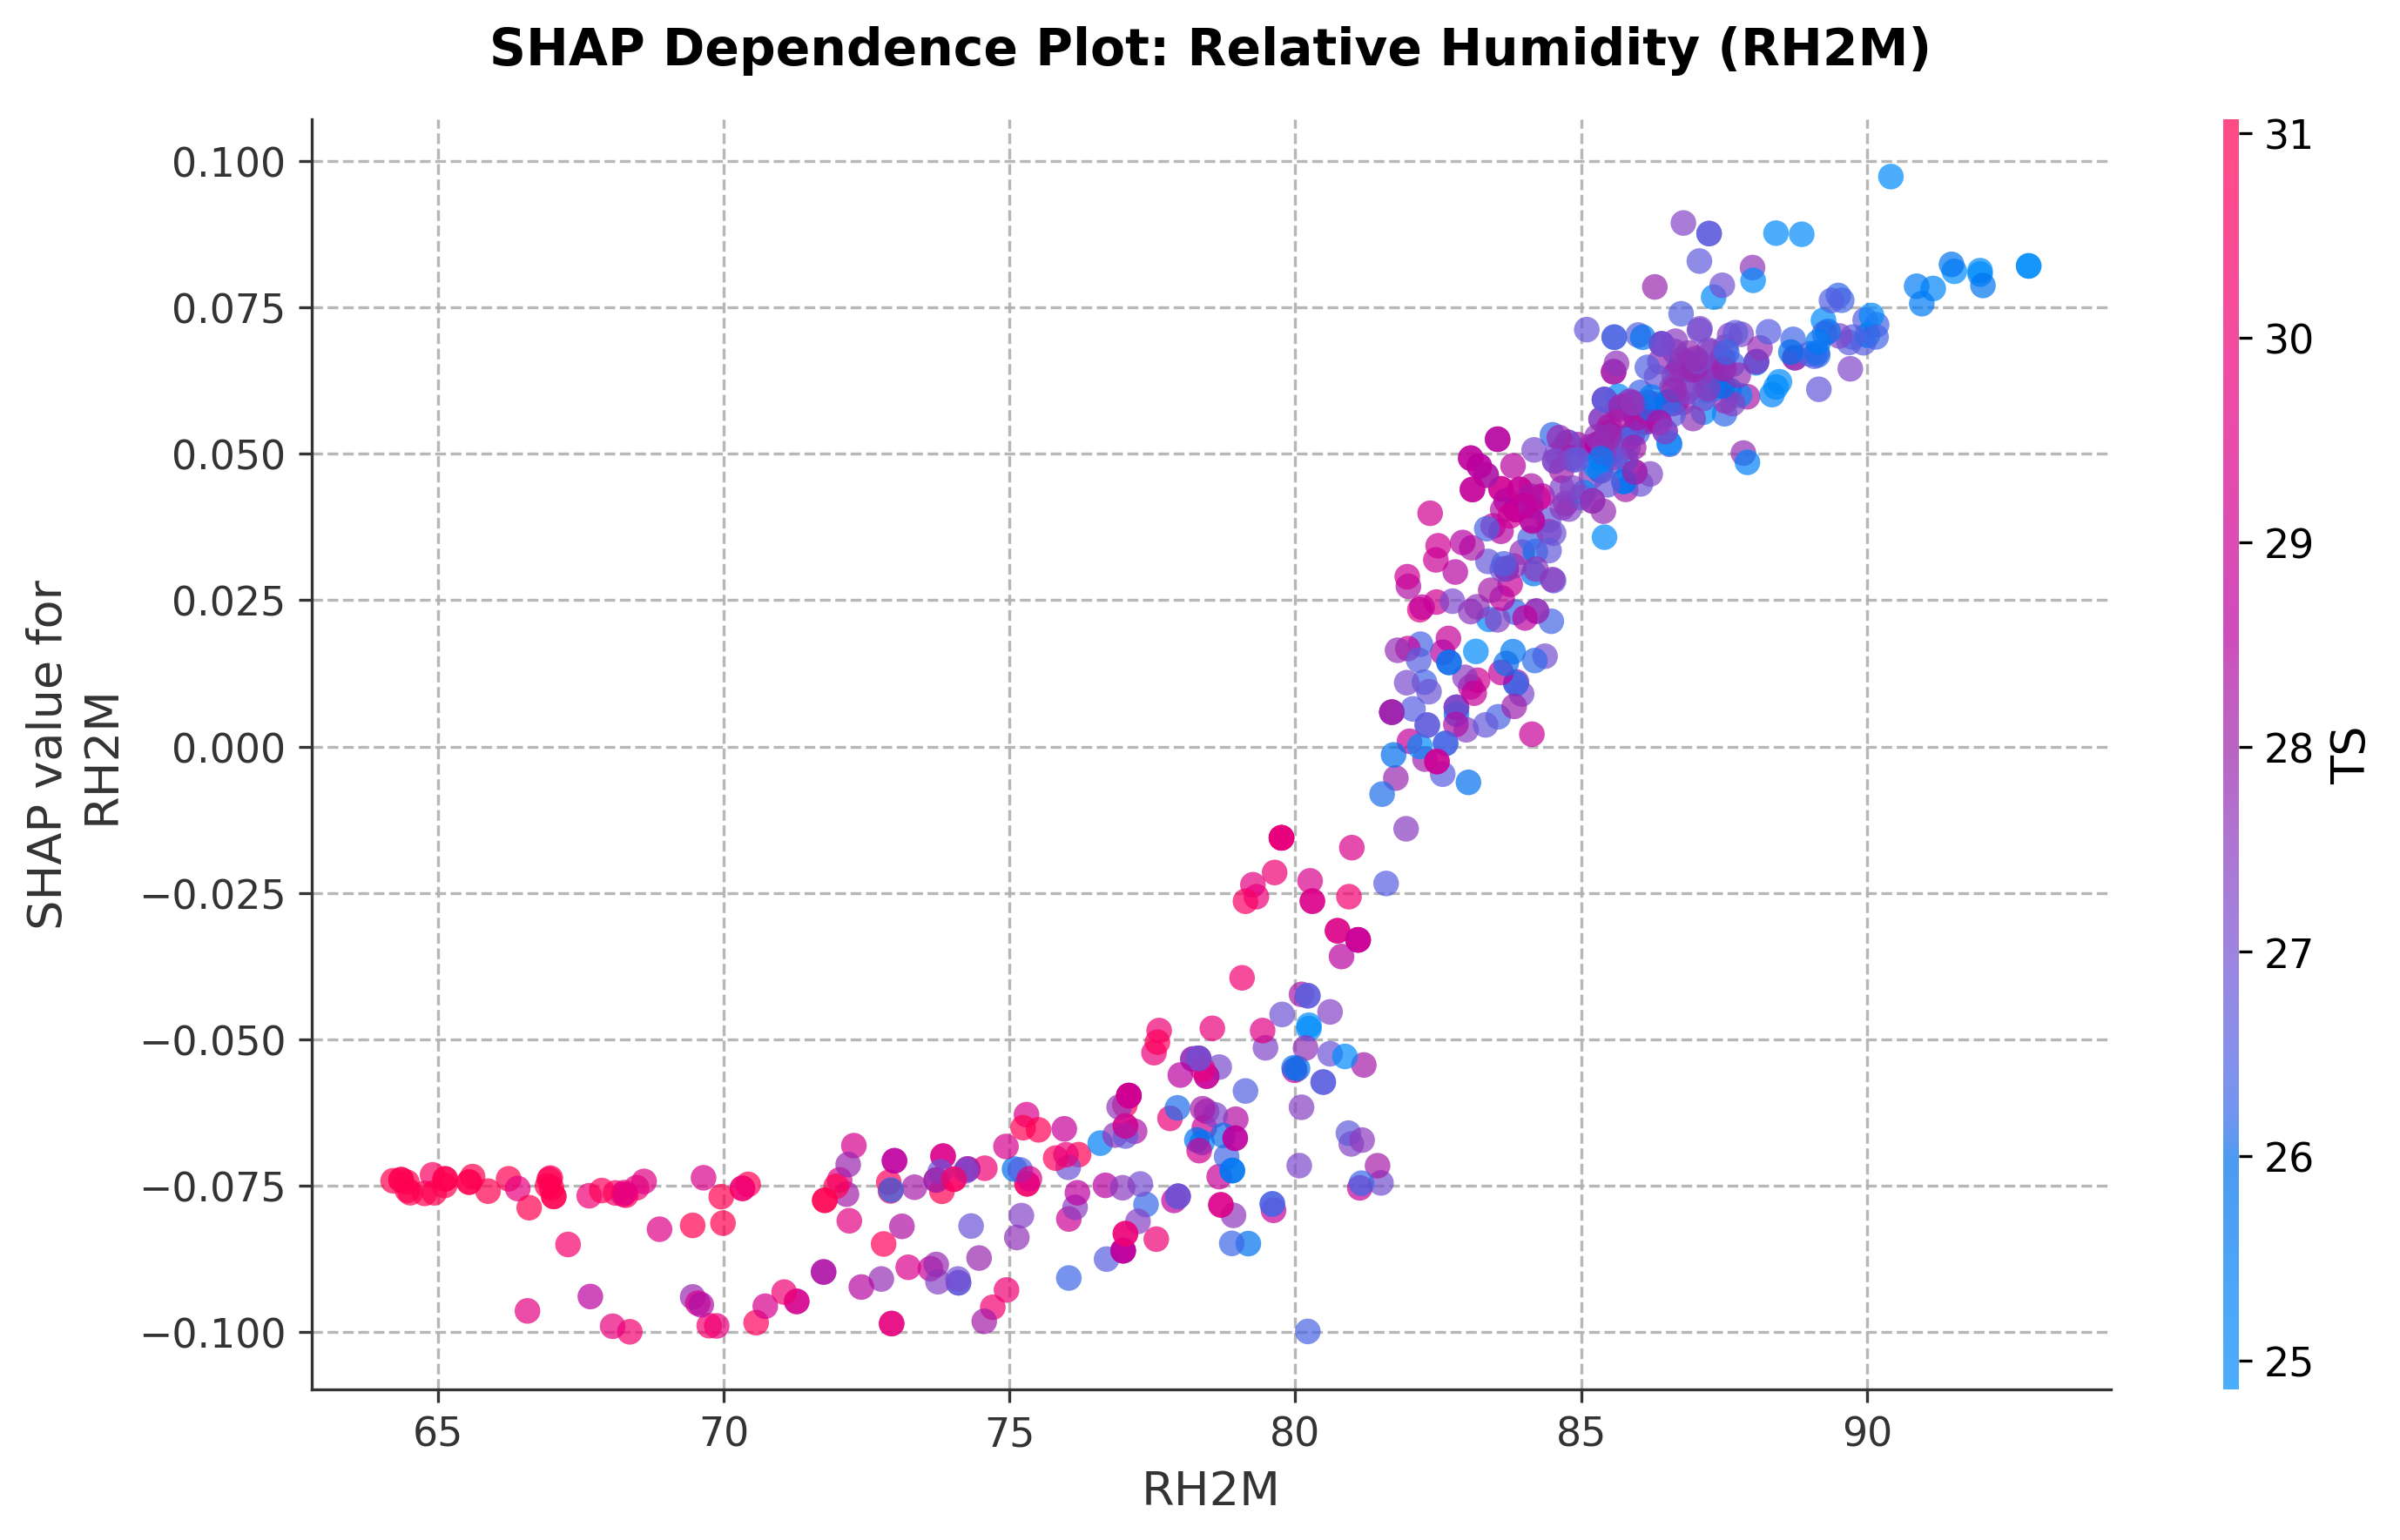

In [22]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
shap.dependence_plot(
    "RH2M",
    shap_values_array,
    sample,
    display_features=X_test,
    ax=ax,
    dot_size=50,
    alpha=0.7,
    show=False
)

# # --- ADDING THE REFERENCE LINES ---
# # 1. Horizontal baseline at SHAP = 0.0 (Neutral Impact)
# ax.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=1)

# # 2. Vertical line at the tipping point (RH2M = 84.5)
# ax.axvline(84.5, color='red', linewidth=1.5, linestyle=':', zorder=1, label="Tipping Point (~84.5)")
# ax.legend(loc="upper left", frameon=True)
# # ----------------------------------

plt.title(
    "SHAP Dependence Plot: Relative Humidity (RH2M)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)
plt.grid(True, axis='both', linestyle='--', alpha=0.9, zorder=0)
ax.set_axisbelow(True) 
plt.tight_layout()
plt.show()

#### Interpretation: RH2M Interaction with Land Evaporation

* ``The Hot & Dry Cluster (Bottom Left)``: The dots on the left are almost entirely bright pink/red, meaning high temperatures ($\approx 30^\circ\text{C}$ to $31^\circ\text{C}$). High heat combined with low humidity creates maximum evaporation, driving the SHAP values down to their lowest negative points.
* ``The Cool & Humid Cluster (Top Right)``: The dots past the tipping point are mostly blue, indicating cooler temperatures ($\approx 25^\circ\text{C}$ to $26^\circ\text{C}$). Cooler air with high humidity prevents evaporation and is often associated with cloud cover or rainfall, driving soil moisture up

# Single City Prediction using the trained Random Forest Model

In [30]:
target_city = "Naic"
city_data = df[df['Municipality'] == target_city].copy()
feature_cols = ["MONTH", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND"]
X_city = city_data[feature_cols]

city_predictions = rf_model.predict(X_city)

city_data['Predicted_GWETROOT'] = city_predictions

# Display the final predictions for that specific city
print(f"--- PREDICTIONS FOR {target_city.upper()} ---")
print(city_data[['MONTH', 'PRECTOTCORR', 'Predicted_GWETROOT']].tail())

--- PREDICTIONS FOR NAIC ---
PARAMETER  MONTH  PRECTOTCORR  Predicted_GWETROOT
9847           8        10.29                0.97
9848           9        16.94                1.00
9849          10        11.12                0.99
9850          11         9.90                0.98
9851          12         3.21                0.95


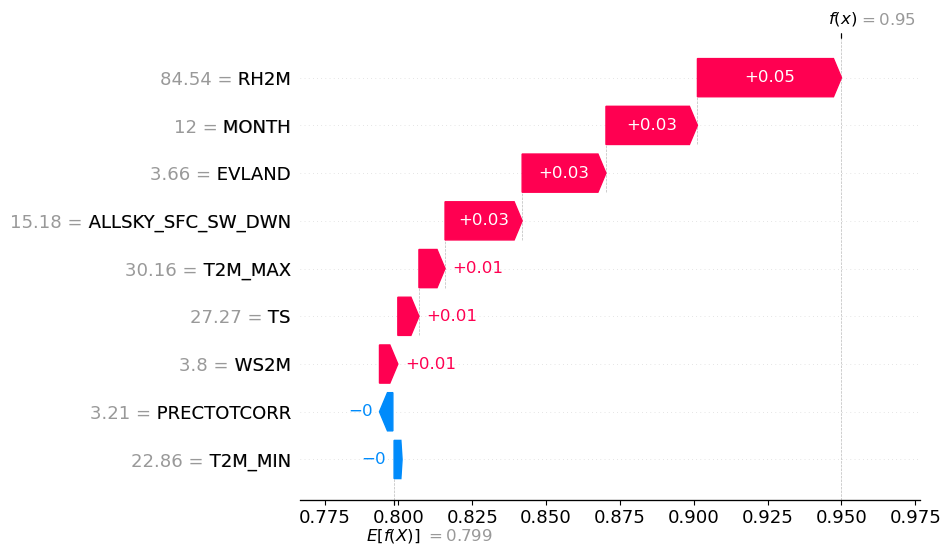

In [31]:
naic_latest_month = X_city.iloc[[-1]] 
explainer = shap.TreeExplainer(rf_model)
explanation = explainer(naic_latest_month, check_additivity=False)
shap.plots.waterfall(explanation[0])